In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/global_air_quality_2014_2025.csv
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/south_korea/south_korea/south_korea_air_quality_2014_2025.csv
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/south_korea/south_korea/README.md
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/usa/usa/README.md
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/usa/usa/usa_air_quality_2014_2025.csv
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/iran/iran/iran_air_quality_2014_2025.csv
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/iran/iran/README.md
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/japan/japan/README.md
/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/japan/japan/japan_air_quality_2014_2025

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional but useful
import warnings
warnings.filterwarnings('ignore')

Input/Source dataset,

Here is the source of dataset https://www.kaggle.com/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025

In [15]:
df = pd.read_csv('/kaggle/input/datasets/ashyou09/world-air-pollution-and-aqi-dataset-20142025/global_air_quality_2014_2025.csv')
df.head()

,Country,State,City,Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),...,Toluene (ug/m3),Xylene (ug/m3),AQI,AQI_Bucket,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT,Population_Density_per_SqKm
0,Australia,Australian Capital Territory,Canberra,2014-01-01,6.85,21.13,3.37,7.16,10.53,6.12,...,2.41,2.54,39.0,Good,12.88,47.47,0.0051,0.77,7.80,343.71
1,Australia,New South Wales,Sydney,2014-01-01,14.88,8.24,2.46,7.41,9.87,2.63,...,2.35,0.78,84.0,Satisfactory,25.59,71.72,0.0055,0.69,7.42,3734.49
2,Australia,New South Wales,Newcastle,2014-01-01,5.57,18.62,2.57,5.44,8.01,4.07,...,1.97,1.38,27.0,Good,26.06,57.64,0.0042,1.17,12.21,371.91
3,Australia,New South Wales,Wollongong,2014-01-01,4.98,19.61,2.52,7.41,9.93,4.67,...,5.07,1.44,35.0,Good,9.97,50.29,0.0025,1.16,4.09,5.00
4,Australia,New South Wales,Central Coast,2014-01-01,4.94,9.70,4.26,12.23,16.49,0.46,...,3.01,2.51,41.0,Good,8.34,45.25,0.0041,1.33,5.44,5.00


Understand the data

What you check:

Number of rows/columns
Data types (numeric, categorical)
Missing values

In [16]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331920 entries, 0 to 331919
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      331920 non-null  object 
 1   State                        331920 non-null  object 
 2   City                         331920 non-null  object 
 3   Date                         331920 non-null  object 
 4   PM2.5 (ug/m3)                331920 non-null  float64
 5   PM10 (ug/m3)                 331920 non-null  float64
 6   NO (ug/m3)                   331920 non-null  float64
 7   NO2 (ug/m3)                  331920 non-null  float64
 8   NOx (ppb)                    331920 non-null  float64
 9   NH3 (ug/m3)                  331920 non-null  float64
 10  CO (mg/m3)                   331920 non-null  float64
 11  SO2 (ug/m3)                  331920 non-null  float64
 12  O3 (ug/m3)                   331920 non-null  float64
 13 

,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),CO (mg/m3),SO2 (ug/m3),O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT,Population_Density_per_SqKm
count,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000
mean,36.572702,73.713076,14.450911,28.243756,29.250374,10.240844,1.027735,10.998873,45.234915,1.577602,4.268308,1.562644,85.833439,11.220079,64.167932,0.507846,3.105886,37.653270,1213.072404
std,46.677615,93.930440,13.972065,23.687724,24.750580,9.791045,1.212356,25.432515,22.495661,1.993388,5.150911,1.701117,60.731897,5.101082,17.882845,0.715380,2.233190,67.108937,2945.946169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,5.000000,0.000000,-4.200000,-3.060000,1.000000
25%,13.300000,23.696756,6.180000,13.580000,13.920000,4.370000,0.396633,3.500000,30.334283,0.550000,1.410000,0.490000,51.000000,7.500000,53.000000,0.022000,1.399972,3.670000,133.400000
50%,21.777052,40.043465,10.288869,21.560000,22.439907,7.418742,0.643352,6.160000,41.320000,1.010000,2.820000,1.070000,70.000000,10.656284,66.000000,0.213000,2.432514,10.010000,429.700000
75%,39.400000,82.220000,17.499505,34.640000,36.146905,12.151323,1.160000,11.740000,55.467659,1.733161,5.020000,2.050000,98.000000,14.261051,77.100000,0.683000,4.600000,34.070000,1173.148422
max,800.000000,1588.180000,155.496505,520.506185,325.905799,91.550000,15.000000,1500.000000,200.000000,30.000000,70.000000,25.000000,672.000000,48.300000,100.000000,8.154000,11.999881,697.060000,28242.658167


"Date" is object → you must convert:

In [19]:
df['Date'] = pd.to_datetime(df['Date'])

Check Again

In [20]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331920 entries, 0 to 331919
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Country                      331920 non-null  object        
 1   State                        331920 non-null  object        
 2   City                         331920 non-null  object        
 3   Date                         331920 non-null  datetime64[ns]
 4   PM2.5 (ug/m3)                331920 non-null  float64       
 5   PM10 (ug/m3)                 331920 non-null  float64       
 6   NO (ug/m3)                   331920 non-null  float64       
 7   NO2 (ug/m3)                  331920 non-null  float64       
 8   NOx (ppb)                    331920 non-null  float64       
 9   NH3 (ug/m3)                  331920 non-null  float64       
 10  CO (mg/m3)                   331920 non-null  float64       
 11  SO2 (ug/m3)               

,Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),CO (mg/m3),SO2 (ug/m3),O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT,Population_Density_per_SqKm
count,331920,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000
mean,2019-12-16 11:00:00.000000256,36.572702,73.713076,14.450911,28.243756,29.250374,10.240844,1.027735,10.998873,45.234915,1.577602,4.268308,1.562644,85.833439,11.220079,64.167932,0.507846,3.105886,37.653270,1213.072404
min,2014-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,5.000000,0.000000,-4.200000,-3.060000,1.000000
25%,2016-12-24 06:00:00,13.300000,23.696756,6.180000,13.580000,13.920000,4.370000,0.396633,3.500000,30.334283,0.550000,1.410000,0.490000,51.000000,7.500000,53.000000,0.022000,1.399972,3.670000,133.400000
50%,2019-12-16 12:00:00,21.777052,40.043465,10.288869,21.560000,22.439907,7.418742,0.643352,6.160000,41.320000,1.010000,2.820000,1.070000,70.000000,10.656284,66.000000,0.213000,2.432514,10.010000,429.700000
75%,2022-12-08 18:00:00,39.400000,82.220000,17.499505,34.640000,36.146905,12.151323,1.160000,11.740000,55.467659,1.733161,5.020000,2.050000,98.000000,14.261051,77.100000,0.683000,4.600000,34.070000,1173.148422
max,2025-12-01 00:00:00,800.000000,1588.180000,155.496505,520.506185,325.905799,91.550000,15.000000,1500.000000,200.000000,30.000000,70.000000,25.000000,672.000000,48.300000,100.000000,8.154000,11.999881,697.060000,28242.658167
std,NaN,46.677615,93.930440,13.972065,23.687724,24.750580,9.791045,1.212356,25.432515,22.495661,1.993388,5.150911,1.701117,60.731897,5.101082,17.882845,0.715380,2.233190,67.108937,2945.946169


Exploratory Data Analysis

let see data distribution

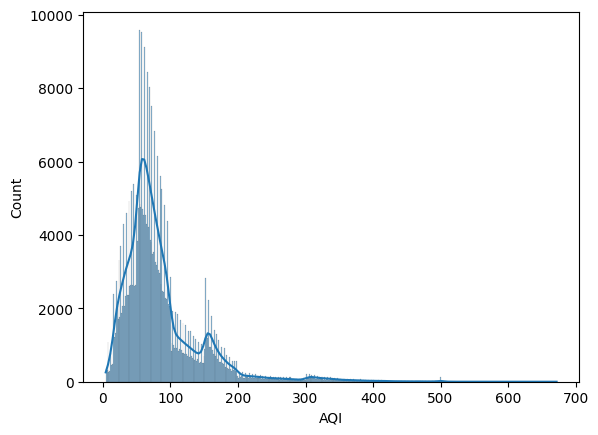

In [21]:
sns.histplot(df['AQI'], kde=True)
plt.show()

Let see trends over time

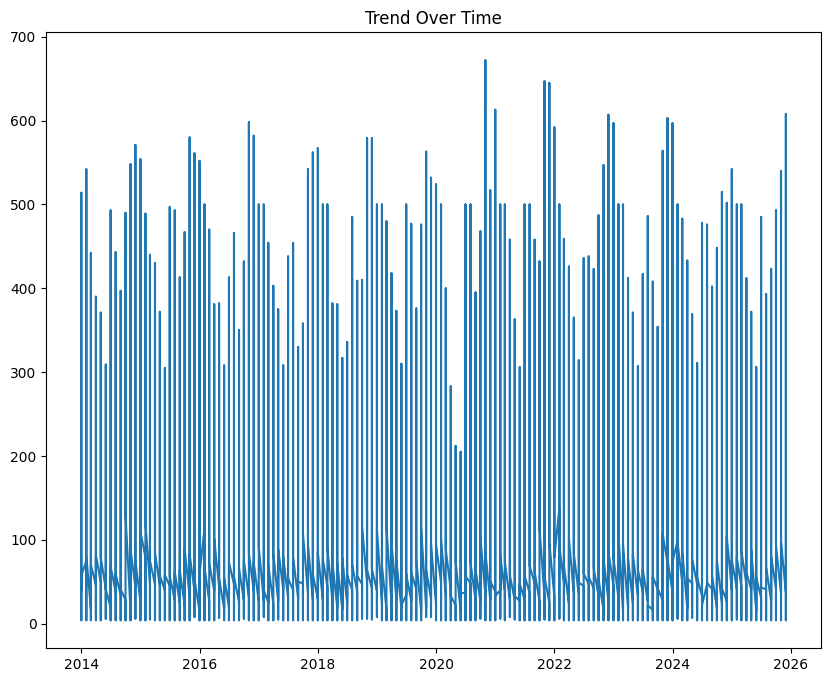

In [22]:
plt.figure(figsize=(10,8))
plt.plot(df['Date'], df['AQI'])
plt.title('Trend Over Time')
plt.show()

Let see correlation

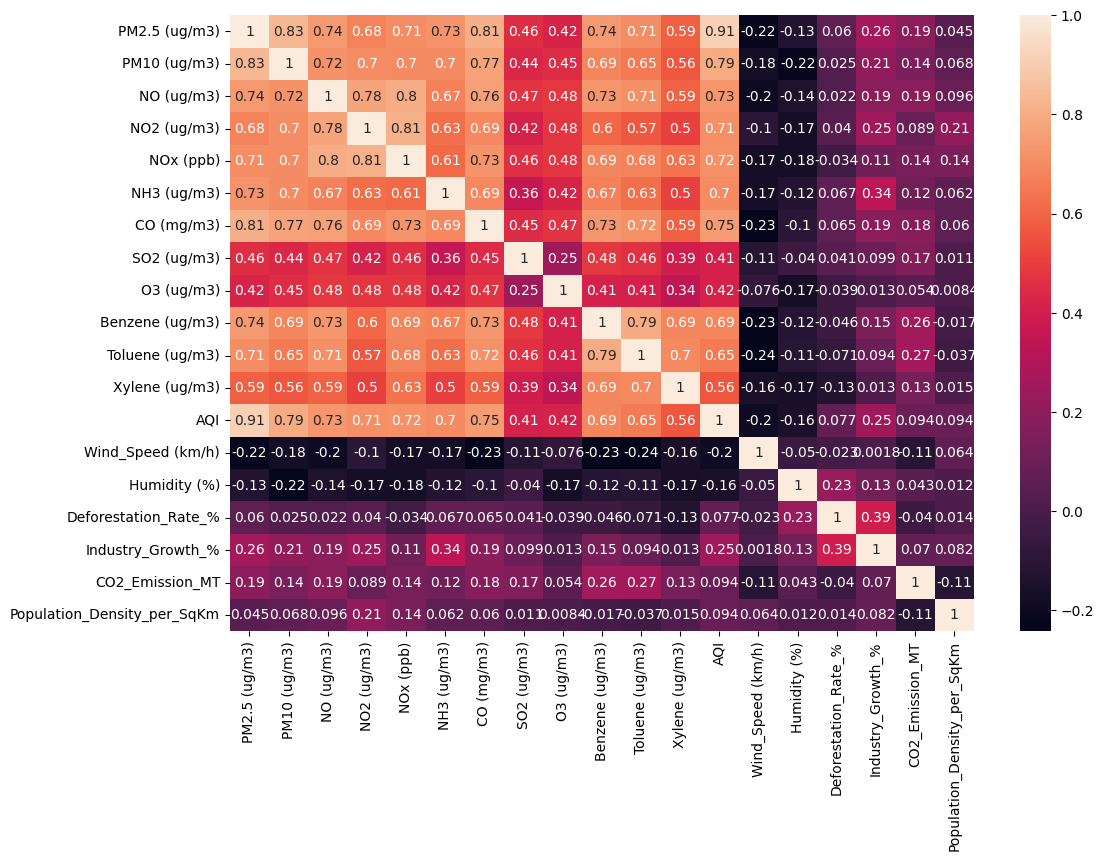

In [24]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
cols = ['AQI', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'CO2_Emission_MT', 'Population_Density_per_SqKm']
#sns.heatmap(numeric_df.corr(), annot=True)
#plt.show()
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

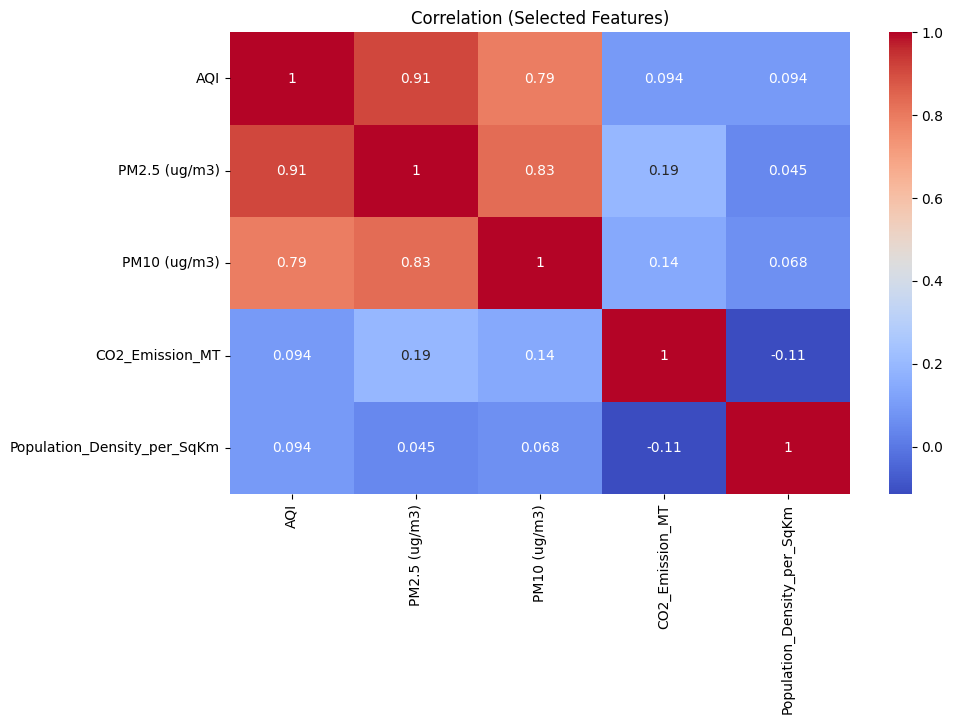

In [25]:
cols = ['AQI', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'CO2_Emission_MT', 'Population_Density_per_SqKm']

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation (Selected Features)')
plt.show()

Analysis

Is air pollution increasing over time?

In [26]:
df['Date'].dtype

dtype('<M8[ns]')

In [29]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

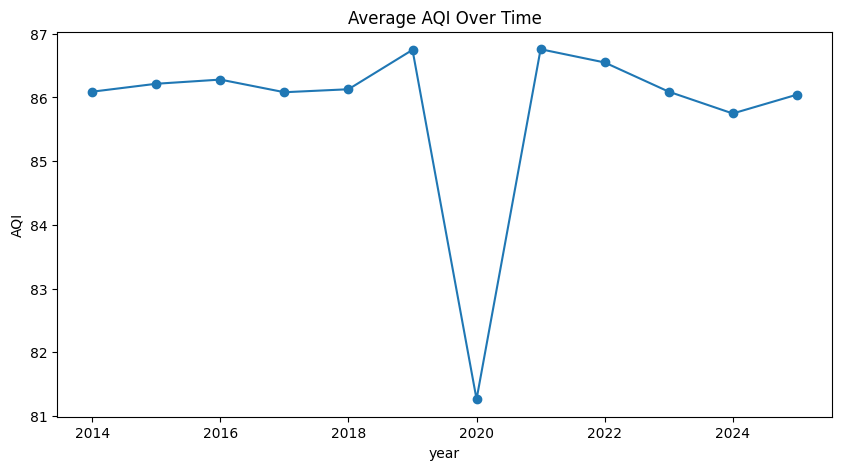

In [30]:
df['year'] = df['Date'].dt.year

yearly_aqi = df.groupby('year')['AQI'].mean()

plt.figure(figsize=(10,5))
yearly_aqi.plot(marker='o')
plt.title('Average AQI Over Time')
plt.ylabel('AQI')
plt.show()

### AQI Trend Over Time

The analysis shows that global AQI levels remain relatively stable between 2014 and 2025, indicating no significant long-term improvement or deterioration in air quality.

However, a noticeable drop in AQI occurs in 2020, where average AQI significantly decreases compared to other years. This anomaly is likely due to reduced human activity during the COVID-19 pandemic, including lockdowns and decreased industrial emissions.

After 2020, AQI levels return to previous levels, suggesting that the improvement in air quality was temporary. This indicates that sustained policy and environmental interventions are required for long-term improvement in air quality.

In [34]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

In [35]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331920 entries, 0 to 331919
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Country                      331920 non-null  object        
 1   State                        331920 non-null  object        
 2   City                         331920 non-null  object        
 3   Date                         331920 non-null  datetime64[ns]
 4   PM2.5 (ug/m3)                331920 non-null  float64       
 5   PM10 (ug/m3)                 331920 non-null  float64       
 6   NO (ug/m3)                   331920 non-null  float64       
 7   NO2 (ug/m3)                  331920 non-null  float64       
 8   NOx (ppb)                    331920 non-null  float64       
 9   NH3 (ug/m3)                  331920 non-null  float64       
 10  CO (mg/m3)                   331920 non-null  float64       
 11  SO2 (ug/m3)               

,Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),CO (mg/m3),SO2 (ug/m3),O3 (ug/m3),...,Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT,Population_Density_per_SqKm,year,month
count,331920,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,...,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000,331920.000000
mean,2019-12-16 11:00:00.000000256,36.572702,73.713076,14.450911,28.243756,29.250374,10.240844,1.027735,10.998873,45.234915,...,1.562644,85.833439,11.220079,64.167932,0.507846,3.105886,37.653270,1213.072404,2019.500000,6.500000
min,2014-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,4.000000,0.000000,5.000000,0.000000,-4.200000,-3.060000,1.000000,2014.000000,1.000000
25%,2016-12-24 06:00:00,13.300000,23.696756,6.180000,13.580000,13.920000,4.370000,0.396633,3.500000,30.334283,...,0.490000,51.000000,7.500000,53.000000,0.022000,1.399972,3.670000,133.400000,2016.750000,3.750000
50%,2019-12-16 12:00:00,21.777052,40.043465,10.288869,21.560000,22.439907,7.418742,0.643352,6.160000,41.320000,...,1.070000,70.000000,10.656284,66.000000,0.213000,2.432514,10.010000,429.700000,2019.500000,6.500000
75%,2022-12-08 18:00:00,39.400000,82.220000,17.499505,34.640000,36.146905,12.151323,1.160000,11.740000,55.467659,...,2.050000,98.000000,14.261051,77.100000,0.683000,4.600000,34.070000,1173.148422,2022.250000,9.250000
max,2025-12-01 00:00:00,800.000000,1588.180000,155.496505,520.506185,325.905799,91.550000,15.000000,1500.000000,200.000000,...,25.000000,672.000000,48.300000,100.000000,8.154000,11.999881,697.060000,28242.658167,2025.000000,12.000000
std,NaN,46.677615,93.930440,13.972065,23.687724,24.750580,9.791045,1.212356,25.432515,22.495661,...,1.701117,60.731897,5.101082,17.882845,0.715380,2.233190,67.108937,2945.946169,3.452058,3.452058


In [32]:
country_aqi = df.groupby('Country')['AQI'].mean().sort_values(ascending=False)

country_aqi.head(10)

Country
Pakistan      187.183984
Bangladesh    183.989675
India         140.105915
Nigeria       126.319155
Egypt         120.847353
Indonesia      90.765588
Mexico         87.760969
Turkey         86.454486
China          83.359205
Ethiopia       82.795481
Name: AQI, dtype: float64